# Experiment 1.3.1.2 — Relative-bin count vs rate

## Research question

Experiment 1.3.1 showed that direct encoder-event representations become increasingly informative when coarse relative temporal position is retained. However, the current relative-bin feature is a **sum** inside each bin. Because each relative bin contains more physical time for a longer gesture, its magnitude can retain segment-duration information even though temporal position has been normalized.

This experiment isolates that effect by comparing two otherwise identical representations over a sweep of relative-bin counts:

- **`relative_bin_count`**: per-channel weighted event sum inside each relative-progress bin. This matches the existing Experiment 1.3 / 1.3.1 behavior.
- **`relative_bin_rate`**: the same weighted event sum divided by the exact physical duration of that bin, yielding weighted event mass per second.

For a sample with valid length $L$, relative bin $b$ contains a contiguous set $W_b$ determined only from that sample's valid prefix. For event channel $c$:

$$z^{count}_{b,c}=\sum_{t\in W_b}x_{t,c}$$

$$z^{rate}_{b,c}=\frac{\sum_{t\in W_b}x_{t,c}}{|W_b|/f_s}=\frac{f_s}{|W_b|}\sum_{t\in W_b}x_{t,c}$$

The **relative-position normalization is identical** in both conditions; only duration normalization differs. Therefore a count-vs-rate gap tests whether the useful signal partly comes from accumulated magnitude / gesture duration rather than only relative temporal organization.

This is still an offline diagnostic: defining relative progress requires the final valid length. It does not make relative binning streaming-causal.

## Protocol

The protocol follows Experiment 1.3.1 as closely as possible:

- direct 30-channel unsigned polarity-split weighted events;
- expected sampling rate 64 Hz;
- labels `A B C D E X G H I J K L`;
- five user-disjoint train/validation/test splits using split seeds `(11, 23, 37, 53, 71)` and the same 60/20/20 user fractions as 1.3.1;
- train-only feature standardization;
- multinomial Logistic Regression and 5-NN;
- Balanced Accuracy as the primary metric, with Accuracy and Macro-F1 also saved.

The relative-bin sweep is:

`1, 2, 4, 6, 8, 10, 12, 16, 20`

This keeps the sweep dense through the low/mid range, includes the existing 10-bin reference, and reaches the 20-bin resolution used in prior direct-event probing. Count and rate always use exactly the same split and exactly the same bin boundaries.

In [1]:
from __future__ import annotations

from pathlib import Path
import hashlib
import json
import os
import random
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from IPython.display import display


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'snn').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate writingRing repository root')


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from snn.accel_reconstruction_eval.datasets import load_acceleration_data

print('Repository root:', REPO_ROOT)
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

Repository root: /home/zhaolongwei_umass_edu/projects/writingRing
PyTorch: 2.11.0+cu128
CUDA available: False


## 1. Configuration

In [2]:
ACTION0_COMBINATION_DIR = REPO_ROOT / 'outputs/action0_wavelets_0e5_1_2_4_8_sr_64'
ACTION1_COMBINATION_DIR = REPO_ROOT / 'outputs/action1_wavelets_0e5_1_2_4_8_sr_64'
DATASET_ROOTS = [
    ACTION0_COMBINATION_DIR / 'low-pass/aligned-board-events/segmentation_padded',
    ACTION1_COMBINATION_DIR / 'low-pass/aligned-board-events/segmentation_padded',
]

EXPECTED_EVENT_REPRESENTATION = 'unsigned'
EXPECTED_EVENT_FEATURE_SCHEMA = 'custom_wavelet_polarity_split_abs_events_v1'
EVENT_CHANNEL_COUNT = 30
TOTAL_CHANNEL_COUNT = EVENT_CHANNEL_COUNT + 6
EXPECTED_SAMPLING_RATE_HZ = 64.0

INCLUDED_LABELS = ('A', 'B', 'C', 'D', 'E', 'X', 'G', 'H', 'I', 'J', 'K', 'L') #('A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L','M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z')#
SPLIT_SEEDS = (11, 23, 37)#, 53, 71
TRAIN_FRACTION = 0.60
VAL_FRACTION = 0.20

RELATIVE_N_BINS = (1, 2, 4, 6, 8, 10, 12, 16, 20)
REPRESENTATION_MODES = ('relative_bin_count', 'relative_bin_rate')

KNN_K = 5
LOGREG_MAX_ITER = 5000
STD_EPS = 1e-8

EXPERIMENT_ID = 'experiment_1_3_1_2_relative_bin_count_vs_rate'
RESULTS_DIR = REPO_ROOT / 'notebooks/artifacts' / EXPERIMENT_ID
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print('Roots:', *DATASET_ROOTS, sep='\n - ')
print('Split seeds:', SPLIT_SEEDS)
print('Relative-bin sweep:', RELATIVE_N_BINS)
print('Representations:', REPRESENTATION_MODES)
print('Results dir:', RESULTS_DIR)

Roots:
 - /home/zhaolongwei_umass_edu/projects/writingRing/outputs/action0_wavelets_0e5_1_2_4_8_sr_64/low-pass/aligned-board-events/segmentation_padded
 - /home/zhaolongwei_umass_edu/projects/writingRing/outputs/action1_wavelets_0e5_1_2_4_8_sr_64/low-pass/aligned-board-events/segmentation_padded
Split seeds: (11, 23, 37)
Relative-bin sweep: (1, 2, 4, 6, 8, 10, 12, 16, 20)
Representations: ('relative_bin_count', 'relative_bin_rate')
Results dir: /home/zhaolongwei_umass_edu/projects/writingRing/notebooks/artifacts/experiment_1_3_1_2_relative_bin_count_vs_rate


## 2. Reproducibility helpers

In [3]:
def derive_seed(master_seed: int, *parts: object) -> int:
    text = '|'.join([str(master_seed), *(str(p) for p in parts)])
    digest = hashlib.sha256(text.encode('utf-8')).digest()
    return int.from_bytes(digest[:4], 'little', signed=False)


def seed_everything(seed: int) -> None:
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except TypeError:
        torch.use_deterministic_algorithms(True)

## 3. Load and validate the same direct-event cohort as Experiment 1.3.1

In [4]:
seed_everything(2026)
data = load_acceleration_data(DATASET_ROOTS, repository_root=REPO_ROOT, require_reconstruction=False)

sampling_rates = {float(m.sampling_rate_hz) for m in data.producer_metadatas}
if len(sampling_rates) != 1:
    raise ValueError(f'Expected one shared sampling rate, got {sampling_rates}')
SAMPLING_RATE_HZ = sampling_rates.pop()
if not np.isclose(SAMPLING_RATE_HZ, EXPECTED_SAMPLING_RATE_HZ):
    raise ValueError((SAMPLING_RATE_HZ, EXPECTED_SAMPLING_RATE_HZ))

for root, metadata in zip(data.padded_roots, data.producer_metadatas, strict=True):
    raw = metadata.raw
    if raw.get('event_representation') != EXPECTED_EVENT_REPRESENTATION:
        raise ValueError(f'{root}: unexpected event representation')
    if raw.get('event_feature_schema') != EXPECTED_EVENT_FEATURE_SCHEMA:
        raise ValueError(f'{root}: unexpected event feature schema')
    if raw.get('event_channel_count') != EVENT_CHANNEL_COUNT:
        raise ValueError(f'{root}: expected {EVENT_CHANNEL_COUNT} event channels')
    if metadata.channel_count != TOTAL_CHANNEL_COUNT:
        raise ValueError(f'{root}: expected {TOTAL_CHANNEL_COUNT} total channels')

rows = []
keep = set(INCLUDED_LABELS)
for package_index, package in enumerate(data.packages):
    for segment_index, label in enumerate(package.labels.astype(str)):
        label = str(label)
        if label not in keep:
            continue
        L = int(package.valid_lengths[segment_index])
        if L <= 0:
            raise ValueError('valid_length must be positive')
        rows.append({
            'package_index': package_index,
            'segment_index': segment_index,
            'user': str(package.user),
            'action': str(package.action),
            'label': label,
            'valid_length': L,
            'sample_id': f'{package.user}/action_{package.action}/{segment_index}',
        })

manifest = pd.DataFrame(rows)
labels_sorted = sorted(manifest.label.unique().tolist())
CLASS_TO_IDX = {lab: i for i, lab in enumerate(labels_sorted)}
manifest['label_idx'] = manifest.label.map(CLASS_TO_IDX).astype(int)

if min(manifest.valid_length) < max(RELATIVE_N_BINS):
    raise ValueError('At least one requested n_bins exceeds a sample valid_length')

print(f'Loaded {len(manifest)} samples from {manifest.user.nunique()} users')
print('Classes:', len(labels_sorted), labels_sorted)
print('Sampling rate:', SAMPLING_RATE_HZ)
print('Valid-length range:', int(manifest.valid_length.min()), '..', int(manifest.valid_length.max()))
display(manifest.head())

Loaded 853 samples from 20 users
Classes: 12 ['A', 'B', 'C', 'D', 'E', 'G', 'H', 'I', 'J', 'K', 'L', 'X']
Sampling rate: 64.0
Valid-length range: 44 .. 247


,package_index,segment_index,user,action,label,valid_length,sample_id,label_idx
0,0,24,user_0,0,J,72,user_0/action_0/24,8
1,0,25,user_0,0,B,128,user_0/action_0/25,1
2,0,26,user_0,0,X,106,user_0/action_0/26,11
3,0,27,user_0,0,E,122,user_0/action_0/27,4
4,0,31,user_0,0,G,124,user_0/action_0/31,5


## 4. User-disjoint split and relative-bin feature builders

`np.array_split` is used exactly to handle valid lengths that are not divisible by the requested number of bins. Therefore adjacent bins may differ by one timestep, and the rate representation divides by the **actual** number of timesteps in each bin rather than by an approximate common bin length.

In [5]:
def make_user_split(manifest: pd.DataFrame, split_seed: int) -> pd.DataFrame:
    users = sorted(manifest['user'].unique().tolist())
    if len(users) < 3:
        raise ValueError('Need at least 3 users for user-disjoint splitting')
    rng = np.random.default_rng(derive_seed(split_seed, 'user_split'))
    perm = np.array(users, dtype=object)
    rng.shuffle(perm)
    n = len(perm)
    n_train = max(1, int(np.floor(TRAIN_FRACTION * n)))
    n_val = max(1, int(np.floor(VAL_FRACTION * n)))
    if n_train + n_val >= n:
        n_train = n - 2
        n_val = 1
    train_users = set(perm[:n_train].tolist())
    val_users = set(perm[n_train:n_train + n_val].tolist())
    test_users = set(perm[n_train + n_val:].tolist())
    out = manifest.copy()
    out['split'] = 'test'
    out.loc[out.user.isin(train_users), 'split'] = 'train'
    out.loc[out.user.isin(val_users), 'split'] = 'val'
    return out


def build_relative_features(df: pd.DataFrame, n_bins: int, mode: str):
    if mode not in REPRESENTATION_MODES:
        raise ValueError(mode)
    features, labels, sample_ids, bin_lengths = [], [], [], []
    for row in df.itertuples(index=False):
        package = data.packages[int(row.package_index)]
        i = int(row.segment_index)
        L = int(row.valid_length)
        x = np.asarray(package.padded_spike_imu[i, :L, :EVENT_CHANNEL_COUNT], dtype=np.float64)
        if n_bins > L:
            raise ValueError(f'n_bins={n_bins} exceeds valid_length={L} for {row.sample_id}')
        chunks = np.array_split(x, n_bins, axis=0)
        counts = np.stack([chunk.sum(axis=0) for chunk in chunks], axis=0)
        lengths = np.asarray([len(chunk) for chunk in chunks], dtype=np.float64)
        if np.any(lengths <= 0):
            raise RuntimeError('Empty relative bin encountered')
        if mode == 'relative_bin_count':
            z = counts
        else:
            durations_s = lengths / SAMPLING_RATE_HZ
            z = counts / durations_s[:, None]
        features.append(z.reshape(-1))
        labels.append(int(row.label_idx))
        sample_ids.append(str(row.sample_id))
        bin_lengths.append(lengths.astype(np.int64))
    return (
        np.stack(features).astype(np.float64),
        np.asarray(labels, dtype=np.int64),
        np.asarray(sample_ids, dtype=object),
        np.stack(bin_lengths),
    )

## 5. Probe protocol

As in Experiment 1.3.1, feature scaling is fit **only on the training split** and then applied unchanged to validation and test. This is feature-wise z-scoring, not duration normalization; the count-vs-rate manipulation happens before this shared probe preprocessing.

In [6]:
def standardize_from_train(X_train, *others):
    X_train = np.asarray(X_train, dtype=np.float64)
    mean = X_train.mean(axis=0, keepdims=True)
    std = X_train.std(axis=0, keepdims=True)
    std[std < STD_EPS] = 1.0
    outputs = [(X_train - mean) / std]
    for x in others:
        outputs.append((np.asarray(x, dtype=np.float64) - mean) / std)
    return outputs


def classification_metrics(y_true, y_pred):
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'macro_f1': float(f1_score(y_true, y_pred, average='macro')),
    }


def evaluate_probes(X_train, y_train, X_val, y_val, X_test, y_test, *, split_seed, condition_name):
    seed_everything(derive_seed(split_seed, condition_name, 'fit'))
    X_train_z, X_val_z, X_test_z = standardize_from_train(X_train, X_val, X_test)

    logreg = LogisticRegression(
        max_iter=LOGREG_MAX_ITER,
        random_state=derive_seed(split_seed, condition_name, 'logreg'),
        solver='lbfgs',
    )
    logreg.fit(X_train_z, y_train)

    knn = KNeighborsClassifier(
        n_neighbors=KNN_K,
        weights='uniform',
        metric='minkowski',
        p=2,
        n_jobs=-1,
    )
    knn.fit(X_train_z, y_train)

    rows = []
    for model_name, model in (('logreg', logreg), ('knn5', knn)):
        for split_name, X, y in (('val', X_val_z, y_val), ('test', X_test_z, y_test)):
            m = classification_metrics(y, model.predict(X))
            rows.append({'probe': model_name, 'eval_split': split_name, **m})
    return rows

## 6. Run paired count-vs-rate sweep

For every split seed and every `n_bins`, count and rate are evaluated on the same samples with the same user split and the same bin boundaries. This makes the paired difference `rate - count` directly interpretable.

In [7]:
result_rows = []
split_rows = []

for split_seed in SPLIT_SEEDS:
    split_manifest = make_user_split(manifest, split_seed)
    train_df = split_manifest[split_manifest.split == 'train'].reset_index(drop=True)
    val_df = split_manifest[split_manifest.split == 'val'].reset_index(drop=True)
    test_df = split_manifest[split_manifest.split == 'test'].reset_index(drop=True)

    split_rows.append({
        'split_seed': split_seed,
        'train_users': '|'.join(sorted(train_df.user.unique())),
        'val_users': '|'.join(sorted(val_df.user.unique())),
        'test_users': '|'.join(sorted(test_df.user.unique())),
        'n_train': len(train_df),
        'n_val': len(val_df),
        'n_test': len(test_df),
    })

    print('=' * 100)
    print('SPLIT SEED:', split_seed, '| train/val/test:', len(train_df), len(val_df), len(test_df))

    for n_bins in RELATIVE_N_BINS:
        for mode in REPRESENTATION_MODES:
            Xtr, ytr, _, train_bin_lengths = build_relative_features(train_df, n_bins, mode)
            Xva, yva, _, val_bin_lengths = build_relative_features(val_df, n_bins, mode)
            Xte, yte, _, test_bin_lengths = build_relative_features(test_df, n_bins, mode)

            condition = f'{mode}_{n_bins}bin'
            probe_rows = evaluate_probes(
                Xtr, ytr, Xva, yva, Xte, yte,
                split_seed=split_seed, condition_name=condition,
            )
            for row in probe_rows:
                result_rows.append({
                    'split_seed': split_seed,
                    'representation': mode,
                    'n_bins': n_bins,
                    'feature_dim': int(Xtr.shape[1]),
                    'mean_train_bin_samples': float(train_bin_lengths.mean()),
                    'mean_val_bin_samples': float(val_bin_lengths.mean()),
                    'mean_test_bin_samples': float(test_bin_lengths.mean()),
                    **row,
                })

            test_logreg_ba = [r['balanced_accuracy'] for r in probe_rows if r['probe'] == 'logreg' and r['eval_split'] == 'test'][0]
            print(f'{n_bins:2d} bins | {mode:18s} | dim={Xtr.shape[1]:3d} | logreg test BA={test_logreg_ba:.4f}')

results_df = pd.DataFrame(result_rows)
split_df = pd.DataFrame(split_rows)
results_df.to_csv(RESULTS_DIR / 'experiment_1_3_1_2_results.csv', index=False)
split_df.to_csv(RESULTS_DIR / 'experiment_1_3_1_2_split_manifest.csv', index=False)
display(results_df.head())
display(split_df)

SPLIT SEED: 11 | train/val/test: 477 168 208
 1 bins | relative_bin_count | dim= 30 | logreg test BA=0.4412
 1 bins | relative_bin_rate  | dim= 30 | logreg test BA=0.4331
 2 bins | relative_bin_count | dim= 60 | logreg test BA=0.6458
 2 bins | relative_bin_rate  | dim= 60 | logreg test BA=0.5793
 4 bins | relative_bin_count | dim=120 | logreg test BA=0.7801
 4 bins | relative_bin_rate  | dim=120 | logreg test BA=0.7372
 6 bins | relative_bin_count | dim=180 | logreg test BA=0.8006
 6 bins | relative_bin_rate  | dim=180 | logreg test BA=0.7866
 8 bins | relative_bin_count | dim=240 | logreg test BA=0.8469
 8 bins | relative_bin_rate  | dim=240 | logreg test BA=0.8194
10 bins | relative_bin_count | dim=300 | logreg test BA=0.8178
10 bins | relative_bin_rate  | dim=300 | logreg test BA=0.8172
12 bins | relative_bin_count | dim=360 | logreg test BA=0.8209
12 bins | relative_bin_rate  | dim=360 | logreg test BA=0.8067
16 bins | relative_bin_count | dim=480 | logreg test BA=0.7858
16 bins | 

,split_seed,representation,n_bins,feature_dim,mean_train_bin_samples,mean_val_bin_samples,mean_test_bin_samples,probe,eval_split,accuracy,balanced_accuracy,macro_f1
0,11,relative_bin_count,1,30,97.595388,105.779762,90.605769,logreg,val,0.339286,0.339892,0.322741
1,11,relative_bin_count,1,30,97.595388,105.779762,90.605769,logreg,test,0.451923,0.441170,0.435243
2,11,relative_bin_count,1,30,97.595388,105.779762,90.605769,knn5,val,0.285714,0.271154,0.255391
3,11,relative_bin_count,1,30,97.595388,105.779762,90.605769,knn5,test,0.302885,0.297522,0.294056
4,11,relative_bin_rate,1,30,97.595388,105.779762,90.605769,logreg,val,0.279762,0.265995,0.256726


,split_seed,train_users,val_users,test_users,n_train,n_val,n_test
0,11,user_0|user_10|user_13|user_15|user_18|user_19...,user_11|user_12|user_16|user_9,user_1|user_14|user_2|user_3,477,168,208
1,23,user_0|user_1|user_12|user_13|user_15|user_18|...,user_10|user_11|user_14|user_3,user_16|user_5|user_6|user_8,495,181,177
2,37,user_0|user_11|user_12|user_15|user_16|user_18...,user_1|user_13|user_20|user_5,user_10|user_14|user_4|user_9,519,176,158


## 7. Aggregate across the five user splits

In [8]:
summary_df = (
    results_df[results_df.eval_split == 'test']
    .groupby(['representation', 'n_bins', 'probe'], as_index=False)
    .agg(
        n_splits=('split_seed', 'count'),
        mean_balanced_accuracy=('balanced_accuracy', 'mean'),
        sd_balanced_accuracy=('balanced_accuracy', 'std'),
        mean_accuracy=('accuracy', 'mean'),
        sd_accuracy=('accuracy', 'std'),
        mean_macro_f1=('macro_f1', 'mean'),
        sd_macro_f1=('macro_f1', 'std'),
    )
)
summary_df.to_csv(RESULTS_DIR / 'experiment_1_3_1_2_summary.csv', index=False)
display(summary_df)

,representation,n_bins,probe,n_splits,mean_balanced_accuracy,sd_balanced_accuracy,mean_accuracy,sd_accuracy,mean_macro_f1,sd_macro_f1
0,relative_bin_count,1,knn5,3,0.284487,0.013462,0.292170,0.010238,0.273061,0.018240
1,relative_bin_count,1,logreg,3,0.408030,0.029700,0.423365,0.024839,0.397184,0.035856
2,relative_bin_count,2,knn5,3,0.460125,0.012047,0.469931,0.011741,0.452278,0.012105
3,relative_bin_count,2,logreg,3,0.567537,0.082239,0.571383,0.086403,0.564588,0.076894
4,relative_bin_count,4,knn5,3,0.568992,0.025619,0.583606,0.023363,0.565235,0.021667
5,relative_bin_count,4,logreg,3,0.686650,0.080971,0.688534,0.083624,0.684916,0.078424
6,relative_bin_count,6,knn5,3,0.605971,0.077770,0.613883,0.073688,0.602828,0.078163
7,relative_bin_count,6,logreg,3,0.701495,0.089637,0.703782,0.091985,0.705380,0.084045
8,relative_bin_count,8,knn5,3,0.571552,0.060498,0.583424,0.069009,0.571920,0.058121
9,relative_bin_count,8,logreg,3,0.741750,0.091632,0.743140,0.093549,0.741565,0.090570


## 8. Paired `rate - count` effect

A positive delta means duration-normalized rate performs better than raw accumulated count for the same split, bin number, and classifier. A negative delta means the raw count representation contains useful information that is removed by duration normalization.

In [9]:
test_df_results = results_df[results_df.eval_split == 'test'].copy()
paired = test_df_results.pivot_table(
    index=['split_seed', 'n_bins', 'probe'],
    columns='representation',
    values='balanced_accuracy',
).reset_index()
paired['delta_rate_minus_count_BA'] = paired['relative_bin_rate'] - paired['relative_bin_count']
paired_summary = (
    paired.groupby(['n_bins', 'probe'], as_index=False)
    .agg(
        mean_count_BA=('relative_bin_count', 'mean'),
        mean_rate_BA=('relative_bin_rate', 'mean'),
        mean_delta_rate_minus_count_BA=('delta_rate_minus_count_BA', 'mean'),
        sd_delta_rate_minus_count_BA=('delta_rate_minus_count_BA', 'std'),
    )
)
paired.to_csv(RESULTS_DIR / 'experiment_1_3_1_2_paired_by_split.csv', index=False)
paired_summary.to_csv(RESULTS_DIR / 'experiment_1_3_1_2_paired_summary.csv', index=False)
display(paired_summary)

,n_bins,probe,mean_count_BA,mean_rate_BA,mean_delta_rate_minus_count_BA,sd_delta_rate_minus_count_BA
0,1,knn5,0.284487,0.201120,-0.083366,0.031570
1,1,logreg,0.408030,0.372673,-0.035357,0.027658
2,2,knn5,0.460125,0.343454,-0.116671,0.048675
3,2,logreg,0.567537,0.513043,-0.054494,0.039523
4,4,knn5,0.568992,0.497649,-0.071343,0.065132
5,4,logreg,0.686650,0.657290,-0.029360,0.012178
6,6,knn5,0.605971,0.538666,-0.067306,0.040523
7,6,logreg,0.701495,0.685668,-0.015827,0.004621
8,8,knn5,0.571552,0.529619,-0.041934,0.023563
9,8,logreg,0.741750,0.717158,-0.024593,0.002729


## 9. Visualization

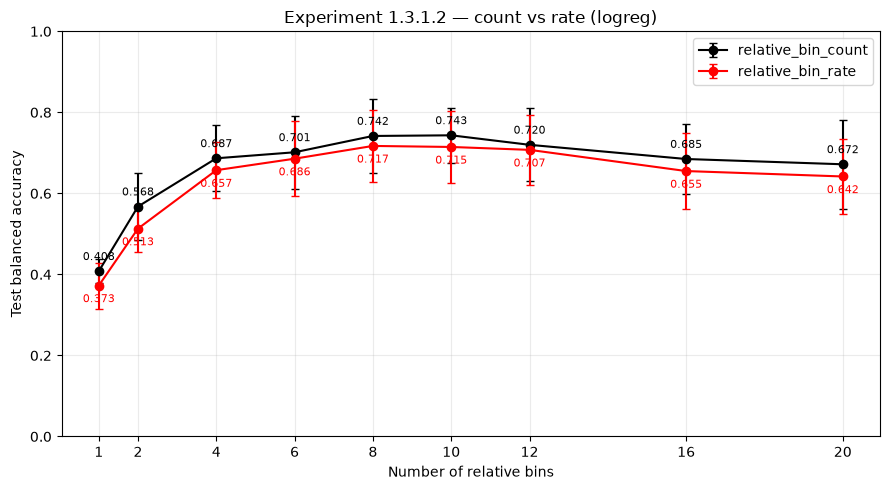

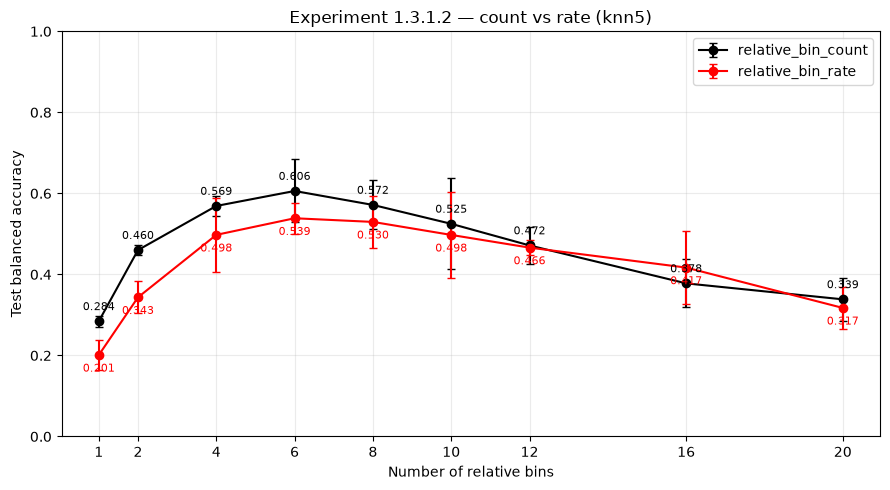

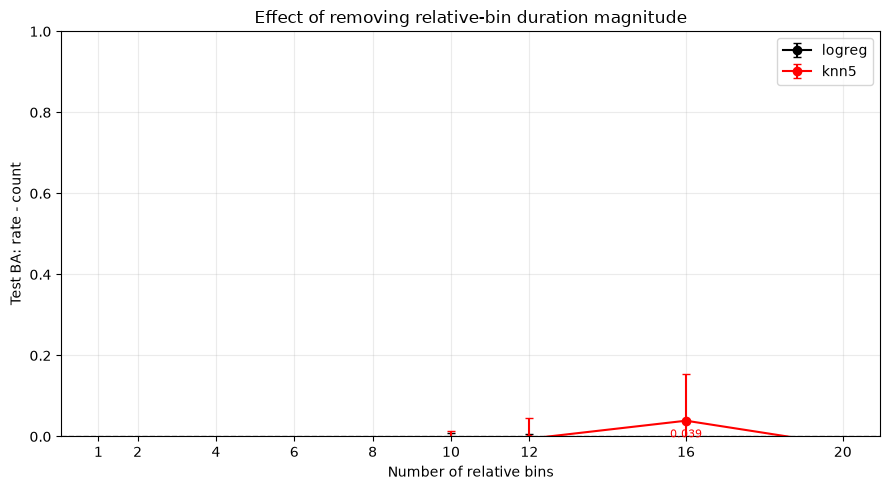

In [13]:
mode_colors = {
    REPRESENTATION_MODES[0]: 'black',
    REPRESENTATION_MODES[1]: 'red',
}

for probe_name in ('logreg', 'knn5'):
    fig, ax = plt.subplots(figsize=(9, 5))
    sub = summary_df[summary_df.probe == probe_name]

    for mode in REPRESENTATION_MODES:
        q = sub[sub.representation == mode].sort_values('n_bins')

        ax.errorbar(
            q.n_bins,
            q.mean_balanced_accuracy,
            yerr=q.sd_balanced_accuracy.fillna(0.0),
            marker='o',
            capsize=3,
            color=mode_colors[mode],
            label=mode,
        )

        # Add value labels near each mean point
        for x, y in zip(q.n_bins, q.mean_balanced_accuracy):
            ax.annotate(
                f'{y:.3f}',
                xy=(x, y),
                xytext=(0, 8 if mode == REPRESENTATION_MODES[0] else -12),
                textcoords='offset points',
                ha='center',
                fontsize=8,
                color=mode_colors[mode],
            )

    ax.set_xlabel('Number of relative bins')
    ax.set_ylabel('Test balanced accuracy')
    ax.set_title(f'Experiment 1.3.1.2 — count vs rate ({probe_name})')
    ax.set_xticks(RELATIVE_N_BINS)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()


probe_colors = {
    'logreg': 'black',
    'knn5': 'red',
}

fig, ax = plt.subplots(figsize=(9, 5))

for probe_name in ('logreg', 'knn5'):
    q = paired_summary[
        paired_summary.probe == probe_name
    ].sort_values('n_bins')

    ax.errorbar(
        q.n_bins,
        q.mean_delta_rate_minus_count_BA,
        yerr=q.sd_delta_rate_minus_count_BA.fillna(0.0),
        marker='o',
        capsize=3,
        color=probe_colors[probe_name],
        label=probe_name,
    )

    # Add value labels near each mean point
    for x, y in zip(q.n_bins, q.mean_delta_rate_minus_count_BA):
        ax.annotate(
            f'{y:.3f}',
            xy=(x, y),
            xytext=(0, 8 if probe_name == 'logreg' else -12),
            textcoords='offset points',
            ha='center',
            fontsize=8,
            color=probe_colors[probe_name],
        )

ax.axhline(0.0, linestyle='--', linewidth=1, color='gray')
ax.set_xlabel('Number of relative bins')
ax.set_ylabel('Test BA: rate - count')
ax.set_title('Effect of removing relative-bin duration magnitude')
ax.set_xticks(RELATIVE_N_BINS)
ax.set_ylim(0, 1)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## 10. Interpretation guide

Use the paired count-vs-rate result rather than only comparing absolute accuracies.

- **Count ≈ Rate across the sweep:** most useful information comes from relative temporal organization / channel composition, not from the physical duration represented by each relative bin.
- **Count > Rate, especially at low bin counts:** accumulated magnitude or gesture duration is itself predictive and contributes to the apparent strength of relative binning.
- **Rate > Count:** duration variation behaves mainly as nuisance scale; removing it improves cross-user representation quality.
- **The gap changes with `n_bins`:** duration information and temporal resolution interact. A small gap at high bin counts would mean bins become physically short enough that duration-scale variation matters less.

Because both representations still use `valid_length` to define relative progress, this experiment does **not** test streaming causality. It specifically tests whether the magnitude inside relative bins should be treated as accumulated count/mass or normalized rate.

In [11]:
provenance = {
    'experiment_id': EXPERIMENT_ID,
    'reference_experiment': 'experiment_1_3_1_event_temporal_representation_probe',
    'sampling_rate_hz': float(SAMPLING_RATE_HZ),
    'event_channels': EVENT_CHANNEL_COUNT,
    'event_representation': EXPECTED_EVENT_REPRESENTATION,
    'event_feature_schema': EXPECTED_EVENT_FEATURE_SCHEMA,
    'split_seeds': list(SPLIT_SEEDS),
    'train_fraction': TRAIN_FRACTION,
    'val_fraction': VAL_FRACTION,
    'relative_n_bins': list(RELATIVE_N_BINS),
    'representation_modes': list(REPRESENTATION_MODES),
    'rate_definition': 'weighted event sum divided by exact bin duration in seconds',
    'knn_k': KNN_K,
    'logreg_max_iter': LOGREG_MAX_ITER,
    'feature_scaling': 'train-only per-feature z-score',
}
with open(RESULTS_DIR / 'experiment_1_3_1_2_provenance.json', 'w') as f:
    json.dump(provenance, f, indent=2)

print('Saved outputs to:', RESULTS_DIR)

Saved outputs to: /home/zhaolongwei_umass_edu/projects/writingRing/notebooks/artifacts/experiment_1_3_1_2_relative_bin_count_vs_rate
